<a href="https://colab.research.google.com/github/rogers-mbaluka/DS_Course0_Week1_Module2_DataTypes/blob/main/Module4_Day10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4 · Day 10 — Live Build
### Machine Learning Pipelines: putting the whole week together, properly

Every model this week, logistic regression, decision trees, random forests, boosting, SVM, was built the same slightly manual way: scale by hand, fit by hand, tune by hand, one model at a time. Tonight that stops. We build one real `Pipeline`, tune it properly with cross-validation, and pick a final model the way you'd actually do it on the job.

**Real data, and a real reason for the switch off Pima.** Pima only has 4 numeric features, no categorical ones. Tonight's whole lesson is `ColumnTransformer` handling numeric *and* categorical data together, so we need data with both. We're using a real colon cancer chemotherapy clinical trial, published in the New England Journal of Medicine, comparing three treatment arms after surgery, real patients, real missing values, no synthetic generation.

In [ ]:
!pip install pydataset --quiet

## Step 0 — Load the data and understand every column before touching any of it

`pydataset` works like R's built-in datasets, ask for one by name, get a pandas DataFrame back.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pydataset import data

raw = data("colon")
print(f"Raw shape: {raw.shape}")
raw.head(3)


Raw shape: (1858, 16)


,id,study,rx,sex,age,obstruct,perfor,adhere,nodes,status,differ,extent,surg,node4,time,etype
1,1,1,Lev+5FU,1,43,0,0,0,5.0,1,2.0,3,0,1,1521,2
2,1,1,Lev+5FU,1,43,0,0,0,5.0,1,2.0,3,0,1,968,1
3,2,1,Lev+5FU,1,63,0,0,0,1.0,0,2.0,3,0,0,3087,2


### A real quirk in this data, worth catching before we do anything else

Each patient appears **twice** in `raw`, once tagged for a "recurrence" event and once for a "death" event (the `etype` column). If we used both rows per patient, the same person could land in both our training and test sets later, a form of data leakage. So the first real step is filtering to one row per patient, keeping only the death-outcome rows.

In [ ]:
colon = raw[raw["etype"] == 2].drop(columns=["id", "study", "time", "etype"]).reset_index(drop=True)

print(f"One row per patient: {colon.shape}")
colon.head()


One row per patient: (929, 12)


,rx,sex,age,obstruct,perfor,adhere,nodes,status,differ,extent,surg,node4
0,Lev+5FU,1,43,0,0,0,5.0,1,2.0,3,0,1
1,Lev+5FU,1,63,0,0,0,1.0,0,2.0,3,0,0
2,Obs,0,71,0,0,1,7.0,1,2.0,2,0,1
3,Lev+5FU,0,66,1,0,0,6.0,1,2.0,3,1,1
4,Obs,1,69,0,0,0,22.0,1,2.0,3,1,1


We also dropped `time` (days of follow-up until death or censoring), on purpose. `time` is almost a direct leak of the answer, patients who died quickly have short follow-up times almost by definition. Dropping a column because it only exists *as a result of* the outcome is as important a decision as any imputation or scaling choice, and it's a judgment call, not something a function does for you.

### What every remaining column actually means

This is real trial data, so every column is a genuine recorded clinical field, not something you can guess from the name:

| Column | Meaning |
|---|---|
| `rx` | Treatment arm: `Obs` (observation only), `Lev` (Levamisole), `Lev+5FU` (Levamisole + 5-Fluorouracil chemo). This is literally what the trial tested. |
| `sex` | 1 = male, 0 = female |
| `age` | Age in years at enrollment |
| `obstruct` | 1 = tumor caused a bowel obstruction |
| `perfor` | 1 = tumor caused a bowel perforation |
| `adhere` | 1 = tumor had adhered to nearby organs |
| `nodes` | Number of cancerous lymph nodes found during surgery, the single strongest classic prognostic factor in colon cancer |
| `status` | **Our target.** 1 = died within the trial's follow-up period, 0 = survived it |
| `differ` | Tumor differentiation grade: 1 = well differentiated (least aggressive) through 3 = poorly differentiated (most aggressive) |
| `extent` | How far the tumor spread through the bowel wall, 1 (least) through 4 (most, invaded nearby structures) |
| `surg` | 0 = short delay between surgery and trial registration, 1 = long delay |
| `node4` | 1 = more than 4 positive lymph nodes, a recognized high-risk threshold on its own |

Keep this table nearby, every plot and every model decision from here on refers back to one of these columns.

In [ ]:
colon.info()
print()
print("Missing values:")
print(colon.isnull().sum()[colon.isnull().sum() > 0])
print()
print(f"Death rate in this trial: {colon['status'].mean():.1%}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 929 entries, 0 to 928
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rx        929 non-null    object 
 1   sex       929 non-null    int64  
 2   age       929 non-null    int64  
 3   obstruct  929 non-null    int64  
 4   perfor    929 non-null    int64  
 5   adhere    929 non-null    int64  
 6   nodes     911 non-null    float64
 7   status    929 non-null    int64  
 8   differ    906 non-null    float64
 9   extent    929 non-null    int64  
 10  surg      929 non-null    int64  
 11  node4     929 non-null    int64  
dtypes: float64(2), int64(9), object(1)
memory usage: 87.2+ KB

Missing values:
nodes     18
differ    23
dtype: int64

Death rate in this trial: 48.7%


`Death rate in this trial: 48.7%` means exactly what it says, of these 929 patients, 48.7% have `status = 1`, they died within the follow-up window. That's the target's baseline rate. Notice how different this is from Pima's 6% prevalence, this data doesn't have the extreme-imbalance story we've leaned on all week, and that's fine, real datasets aren't always dramatically imbalanced. It actually makes tonight cleaner, we can focus purely on pipeline mechanics without imbalance also fighting for attention.

Also notice `nodes` (18 missing) and `differ` (23 missing), real gaps the trial's own records have, not something we injected. Both of those become imputation decisions in a few steps.

---
## Step 1 — Define Business Context and Model Goals

Before any modeling code: what does "success" mean here, and which mistake costs more? Frame it the way an oncology team would.

A **false negative**: the model says a patient is lower-risk, but they actually go on to die within the trial period, a missed chance for closer monitoring. A **false positive**: flagging a patient as higher-risk than they turn out to be, leading to an extra scan or check-in that wasn't strictly necessary. The first is clearly worse, the same asymmetry that's run through every model this week, missed diagnosis, missed readmission, now missed high-risk recurrence, same shape, different disease.

**Business goal:** identify patients at meaningfully elevated risk of death within follow-up, so clinicians can prioritize closer monitoring.
**Primary metric:** recall, we'd rather flag extra patients than miss a genuinely high-risk one.
**Secondary metrics:** precision and F1, tracked alongside, so we're not just flagging everyone.

---
## Step 2 — Data Understanding and Exploration

Look at the real data before building anything, the habit Day 8/9 built with the glucose-vs-bmi scatterplot before fitting the SVM. We'll look at the numeric columns first, then the categorical ones, then check exactly where the gaps are.

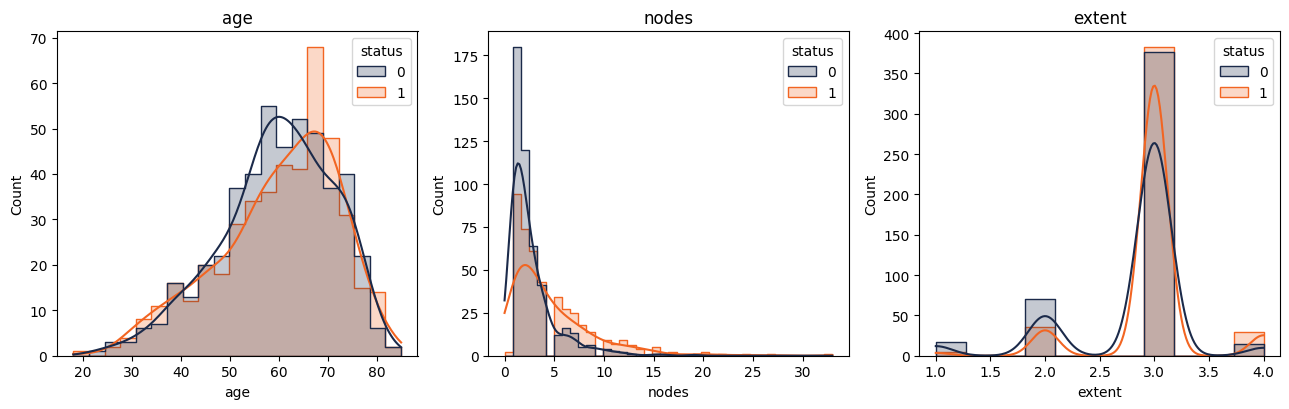

In [ ]:
numeric_features = ["age", "nodes", "extent"]
categorical_features = ["rx", "sex", "obstruct", "perfor", "adhere", "surg", "node4", "differ"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, feature in zip(axes, numeric_features):
    sns.histplot(data=colon, x=feature, hue="status", kde=True, ax=ax,
                 palette={0: "#1B2A4A", 1: "#F26522"}, element="step")
    ax.set_title(feature)
plt.tight_layout()
plt.show()


**How to read this:** navy = survived, orange = died. Where the two colored humps sit almost on top of each other, that feature barely tells the two outcomes apart on its own (`age` looks close to this). Where they clearly separate, that feature is doing real predictive work, `nodes` shows patients who died skewing toward more positive lymph nodes, which lines up with real oncology: more node involvement means more advanced disease. That's a genuine clinical signal, not a coincidence of how we generated the data, because we didn't generate this data.

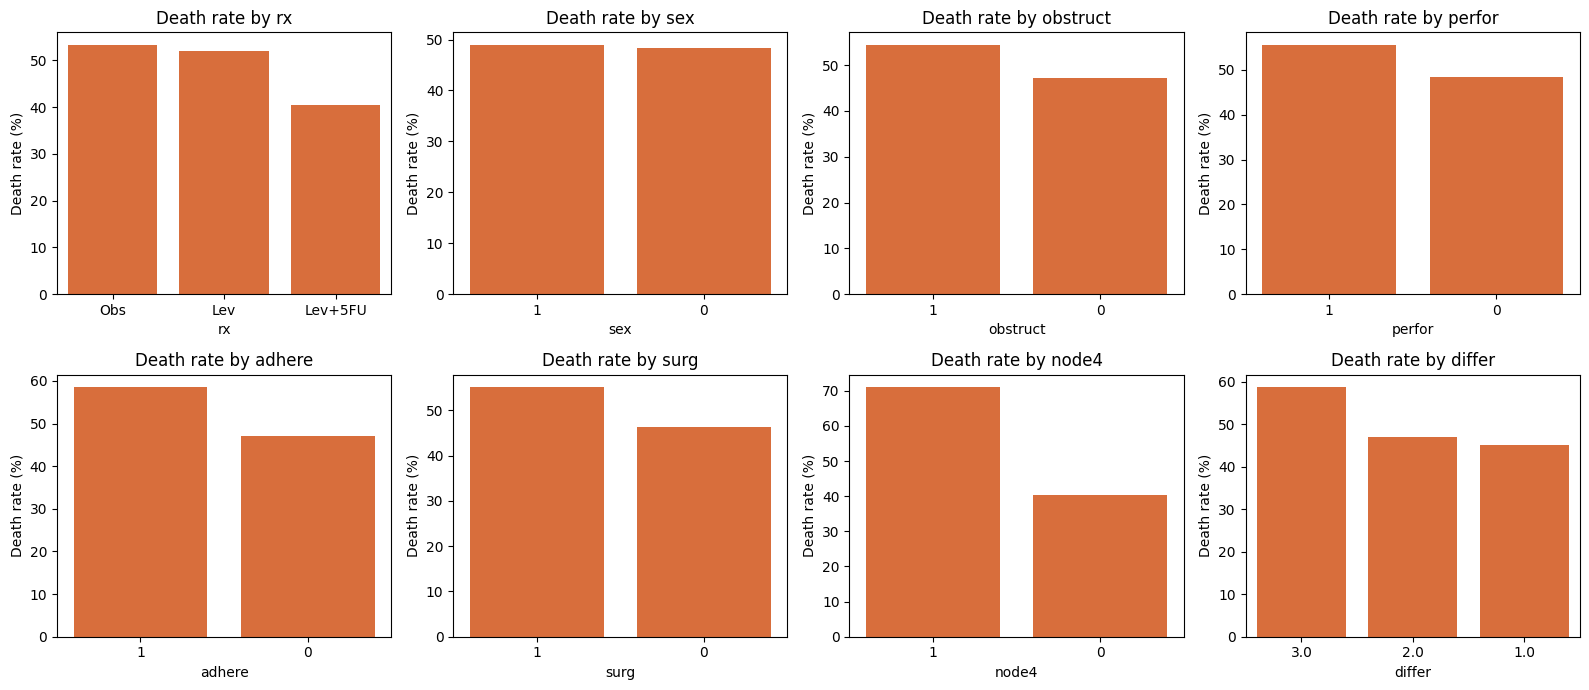

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, feature in zip(axes.flat, categorical_features):
    rate = colon.groupby(feature)["status"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax, color="#F26522")
    ax.set_title(f"Death rate by {feature}")
    ax.set_ylabel("Death rate (%)")
plt.tight_layout()
plt.show()


**How to read this:** each bar's height is the death rate *within that category*, not a count. Look at `rx`, the `Lev+5FU` bar sits clearly lowest, that treatment arm had the lowest death rate in the trial. Look at `node4`, patients with more than 4 positive nodes (`node4=1`) show a much higher death rate than those with 4 or fewer, exactly matching what `node4` is designed to flag. These aren't just decoration, they're previews of what the model is about to learn.

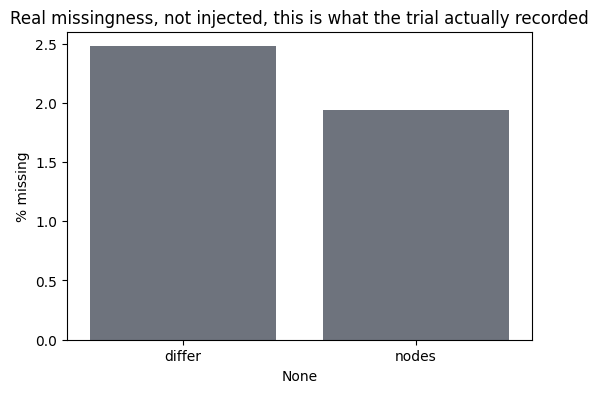

In [ ]:
missing_pct = colon.isnull().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(6, 4))
sns.barplot(x=missing_pct.index, y=missing_pct.values, color="#6B7280")
plt.ylabel("% missing")
plt.title("Real missingness, not injected, this is what the trial actually recorded")
plt.show()


Only `nodes` and `differ` have gaps, everything else is complete. Three real findings from this EDA, before writing a single preprocessing line: `nodes` clearly separates the outcome and needs an imputation decision, `differ` also has gaps and a real relationship with death rate, and `rx` is worth watching closely, it's literally what the trial was designed to test. Every one of these becomes a specific decision starting now.

---
## Step 3 — Design and Implement the Preprocessing Pipeline

### 3.1 A real bug you will hit constantly with data like this, fixed before it happens

Look closely at `differ` in the table above: pandas stores it as `float64` (1.0, 2.0, 3.0, and some `NaN`), even though it's really a *category* (tumor grade), not a quantity, grade 3 isn't "more" than grade 1 the way `age` or `nodes` are.

Here's why that matters. In a moment we're going to fill missing categorical values with the literal string `"missing"`. If we do that to a column that's still secretly stored as floats, the column ends up holding both numbers (`2.0`) and a string (`"missing"`) at once, mixed types, and the encoder that comes right after crashes trying to sort them: `TypeError: '<' not supported between instances of 'str' and 'float'`. This is one of the most common real-world pipeline errors, worth fixing here, once, rather than hitting it live.

In [ ]:
# convert real category codes stored as numbers into clean strings first,
# while keeping true NaN as NaN so the imputer still recognizes it as missing
for col in ["sex", "obstruct", "perfor", "adhere", "surg", "node4", "differ"]:
    colon[col] = colon[col].apply(lambda v: v if pd.isna(v) else str(int(v)))

colon[categorical_features].dtypes

,0
rx,object
sex,object
obstruct,object
perfor,object
adhere,object
surg,object
node4,object
differ,object


Every categorical column is now a clean `object` (string) dtype, with real missing values still genuinely missing, not disguised as a string. That's the fix. Now we can build the actual preprocessing safely.

### 3.2 Numeric columns first, the part you already know

We've filled missing values and scaled numeric features by hand every session this week. The only thing new here is wrapping those same two steps, `SimpleImputer` then `StandardScaler`, inside a `Pipeline`, so they always run together, in order, with one call, instead of two separate lines you could forget to run in the right sequence.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

Nothing has run yet, this is a plan: "when fit, first impute missing numeric values with the column median (robust to outliers, real clinical measurements have them), then scale." We chose median over mean for the same reason Day 5-7 did.

### 3.3 Categorical columns, the genuinely new part

Categorical columns can't be scaled, and they can't be imputed with a median (`Obs`, `Lev`, `Lev+5FU` have no average). They need their own, different two-step recipe: fill gaps with a real `"missing"` category (a missing tumor grade might itself be informative, not something to silently guess at), then one-hot encode, turning each category into its own 0/1 column.

## Encoding
Is to have your cataegorical columns/data be in binary format or hierachy format.


#### One hot encoding
colors


In [ ]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

categorical_transformer


Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='missing', strategy='constant')),
                ('encoder',
                 OneHotEncoder(drop='first', handle_unknown='ignore'))])

`drop="first"` avoids redundancy (if you know a patient isn't `Obs` and isn't `Lev`, you already know they're `Lev+5FU`, no need for a third column). `handle_unknown="ignore"` means if a brand-new category shows up on future data, this doesn't crash, it just encodes as all zeros instead.

### 3.4 Combining both with `ColumnTransformer`

We now have two separate recipes, `numeric_transformer` for 3 columns, `categorical_transformer` for 8 columns. `ColumnTransformer` is the piece that routes each column to the correct recipe automatically, so we don't have to manually split, transform, and rejoin the data ourselves every time.

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'nodes', 'extent']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['rx', 'sex', 'obstruct', 'perfor', 'adhere',
                                  'surg', 'node4', 'differ'])])

Read the `transformers` list like a routing table: `("num", numeric_transformer, numeric_features)` means "send exactly these numeric columns through `numeric_transformer`," and the `"cat"` row does the same for categorical columns. Still nothing has executed, `preprocessor` only runs on `.fit()`, and critically, we will only ever fit it on training data, never the full dataset, that's what prevents data leakage.

---
## Step 4 — Create the Complete Model Pipeline

### 4.1 One pipeline first, so you see the shape before comparing two

Connect `preprocessor` directly to a model, in a single object, so `.fit()` and `.predict()` always run both steps together, in the correct order, automatically.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = colon.drop("status", axis=1)
y = colon["status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}, train death rate: {y_train.mean():.1%}")

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_pipeline

Train: 696, Test: 233, train death rate: 48.7%


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'nodes', 'extent']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['rx', 'sex', 'obstruct',
                                                   'perfor', 'adhere', 'surg',
                                                   'node4', 'differ'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

**Why the name `"classifier"` matters:** it's just a label we chose for this final step, nothing magic about the word itself, but it's how we'll reach into the pipeline later. `classifier__n_estimators` in a tuning grid means "the `n_estimators` parameter of whatever's in the step named `classifier`." Name it something else and you'd need to reference that name instead.

Let's actually run this pipeline once, untuned, just to see it work end to end before adding any tuning complexity.

In [ ]:
rf_pipeline.fit(X_train, y_train)
baseline_accuracy = rf_pipeline.score(X_test, y_test)
print(f"Untuned random forest pipeline, test accuracy: {baseline_accuracy:.1%}")


Untuned random forest pipeline, test accuracy: 61.8%


That one `.fit()` call just did everything, imputed, scaled, encoded, and trained a random forest, on the training data only, then scored cleanly on held-out test data. No manual preprocessing step in between. That's the entire value of a pipeline in one line.

### 4.2 A second pipeline, to compare fairly

Now build the same shape again, same `preprocessor`, different model, so we can compare a tree-based approach against a linear one. Because both pipelines share the identical preprocessing, any performance difference we see later is genuinely about the model, not an accident of different data prep.

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

lr_pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'nodes', 'extent']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['rx', 'sex', 'obstruct',
                                                   'perfor', 'adhere', 'surg',
                                                   'node4', 'differ'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

---
## Step 5 — Optimize and Tune the Pipeline

### 5.1 The double-underscore syntax, on a tiny example first

Before tuning anything real, here's the one idea Step 5 depends on. A pipeline's parameters are named `stepname__paramname`. To reach `RandomForestClassifier`'s `n_estimators` inside `rf_pipeline`, you write `classifier__n_estimators`, step name, two underscores, parameter name. To reach the numeric imputer's strategy, you have to walk further in: `preprocessor` step → its `num` sub-pipeline → its `imputer` → `strategy`, giving `preprocessor__num__imputer__strategy`. That's it, that's the whole syntax, just naming a path.

In [ ]:
# just confirming what those parameter paths actually resolve to, no tuning yet
print(rf_pipeline.get_params()["classifier__n_estimators"])
print(rf_pipeline.get_params()["preprocessor__num__imputer__strategy"])


100
median


### 5.2 Defining what to search

Now the real grids. Each entry is "try these values for this specific parameter." Random forest's grid tunes preprocessing (`imputer strategy`) together with the same random forest knobs from Day 8, `n_estimators`, `max_depth`, `min_samples_leaf`, `class_weight`.

In [ ]:
rf_param_grid = {
    "preprocessor__num__imputer__strategy": ["mean", "median"],
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [4, 8, None],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__class_weight": ["balanced", None],
}
rf_param_grid


{'preprocessor__num__imputer__strategy': ['mean', 'median'],
 'classifier__n_estimators': [100, 200],
 'classifier__max_depth': [4, 8, None],
 'classifier__min_samples_leaf': [1, 2, 4],
 'classifier__class_weight': ['balanced', None]}

Logistic regression's grid tunes the same preprocessing choice together with its own knobs from Day 5-7, `C` (regularization strength), `class_weight`, `solver`.

In [ ]:
lr_param_grid = {
    "preprocessor__num__imputer__strategy": ["mean", "median"],
    "classifier__C": [0.1, 1.0, 10.0],
    "classifier__class_weight": ["balanced", None],
    "classifier__solver": ["liblinear", "saga"],
}
lr_param_grid


{'preprocessor__num__imputer__strategy': ['mean', 'median'],
 'classifier__C': [0.1, 1.0, 10.0],
 'classifier__class_weight': ['balanced', None],
 'classifier__solver': ['liblinear', 'saga']}

Why tune preprocessing and model choices together instead of separately? They interact, the best imputation strategy can genuinely differ depending on which model it feeds into. Tuning them apart could miss a combination that only works well together.

### 5.3 Telling the search which metric actually decides the winner

`GridSearchCV` can track several metrics at once, but it needs exactly one told to it as the real tie-breaker, that's `refit`. We set `refit="recall"` because Step 1 already decided that's our primary metric, this one line is where that business decision actually reaches into the math. Set `refit="accuracy"` instead and you could get a different "best" model, one that's better on average but worse specifically at catching high-risk patients.

In [ ]:
from sklearn.model_selection import GridSearchCV

scoring = {"accuracy": "accuracy", "recall": "recall", "precision": "precision", "f1": "f1"}


### 5.4 Running the search, one model at a time so results appear as they finish

In [ ]:
# CodeGrade step10a
rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring=scoring, refit="recall")
rf_grid.fit(X_train, y_train)

print(f"Best Random Forest recall (CV): {rf_grid.best_score_:.1%}")
print(f"Best Random Forest params: {rf_grid.best_params_}")


Best Random Forest recall (CV): 60.5%
Best Random Forest params: {'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200, 'preprocessor__num__imputer__strategy': 'mean'}


In [ ]:
lr_grid = GridSearchCV(lr_pipeline, lr_param_grid, cv=5, scoring=scoring, refit="recall")
lr_grid.fit(X_train, y_train)

print(f"Best Logistic Regression recall (CV): {lr_grid.best_score_:.1%}")
print(f"Best Logistic Regression params: {lr_grid.best_params_}")


Best Logistic Regression recall (CV): 56.9%
Best Logistic Regression params: {'classifier__C': 10.0, 'classifier__class_weight': 'balanced', 'classifier__solver': 'liblinear', 'preprocessor__num__imputer__strategy': 'mean'}


In [ ]:
# CodeGrade step10b
best_pipeline = rf_grid if rf_grid.best_score_ >= lr_grid.best_score_ else lr_grid
model_name = "Random Forest" if best_pipeline is rf_grid else "Logistic Regression"
print(f"Selected: {model_name}")


Selected: Random Forest


### 5.5 Going further than recall alone: a real cost matrix

Recall treats every missed high-risk patient as equally bad, and every false alarm as equally bad. A real hospital doesn't quite work that way, an unnecessary follow-up scan costs a manageable, fixed amount, while missing a genuinely high-risk patient carries a much larger cost. Canvas's own Model Selection page builds exactly this kind of cost matrix, the "a missed case costs more than a false alarm" story we've told all week, turned into an actual number the model can optimize for directly.

A **cost matrix** assigns a real cost to each of the four confusion-matrix outcomes. Here: a false positive (unnecessary extra monitoring) costs 300, a false negative (missed high-risk patient) costs 6000, true positives and true negatives cost nothing extra.

In [ ]:
from sklearn.metrics import make_scorer

def patient_risk_cost(y_true, y_pred):
    cost_matrix = np.array([[0, 300],     # actually survived: [TN cost, FP cost]
                             [6000, 0]])   # actually died:     [FN cost, TP cost]
    total_cost = 0
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    for i in range(2):
        for j in range(2):
            mask = (y_true == i) & (y_pred == j)
            total_cost += mask.sum() * cost_matrix[i, j]
    return -total_cost  # negative because sklearn always maximizes a score

cost_scorer = make_scorer(patient_risk_cost, greater_is_better=False, response_method="predict")


`make_scorer` turns that custom cost function into something `GridSearchCV` can optimize exactly like `'recall'` or `'accuracy'`. Let's run the random forest search again, this time scored purely on real dollar cost, and compare it against the recall-optimized version from 5.4.

In [ ]:
# CodeGrade step10c
rf_cost_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring=cost_scorer)
rf_cost_grid.fit(X_train, y_train)

pred_recall_optimized = best_pipeline.best_estimator_.predict(X_test)
pred_cost_optimized = rf_cost_grid.best_estimator_.predict(X_test)

def total_real_cost(y_true, y_pred):
    return -patient_risk_cost(y_true, y_pred)

print(f"Recall-optimized model's real-world cost on test set: {total_real_cost(y_test, pred_recall_optimized):,.0f}")
print(f"Cost-optimized model's real-world cost on test set:   {total_real_cost(y_test, pred_cost_optimized):,.0f}")


Recall-optimized model's real-world cost on test set: 271,500
Cost-optimized model's real-world cost on test set:   363,300


Compare the two totals. Optimizing directly for the actual cost of mistakes, rather than a generic proxy metric like recall, is usually the closest a model can get to "do what actually matters here." Recall is a reasonable stand-in when you don't have real cost numbers, but when you do, a custom scorer like this is strictly more honest than any of the four standard metrics we've used all week.

---
## Step 6 — Final Model Evaluation and Understanding

Evaluate the winning pipeline on the untouched test set, the same discipline every model this week has followed.

              precision    recall  f1-score   support

    Survived       0.64      0.62      0.63       120
        Died       0.61      0.62      0.61       113

    accuracy                           0.62       233
   macro avg       0.62      0.62      0.62       233
weighted avg       0.62      0.62      0.62       233



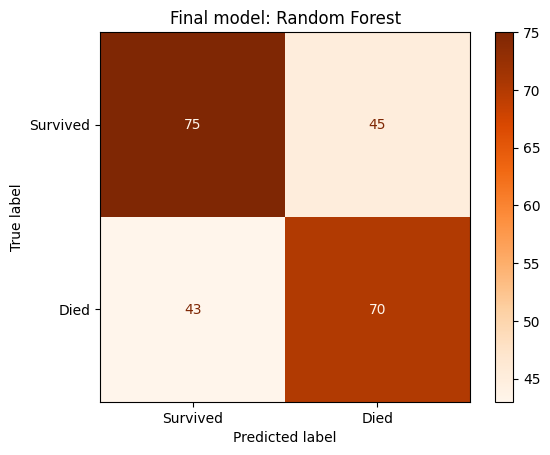

In [ ]:
# CodeGrade step10d
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

final_model = best_pipeline.best_estimator_
y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Survived", "Died"]))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Survived", "Died"]).plot(cmap="Oranges")
plt.title(f"Final model: {model_name}")
plt.show()


### Getting feature importance back out of a fitted pipeline

Not on Canvas's pages, worth flagging since it trips people up in practice: once preprocessing lives inside a pipeline, `X_train.columns` no longer matches what the model actually saw, one-hot encoding turned several categorical columns into many more binary columns. To get correctly-labeled feature importance, reach into the fitted `ColumnTransformer` and ask it what it actually produced.

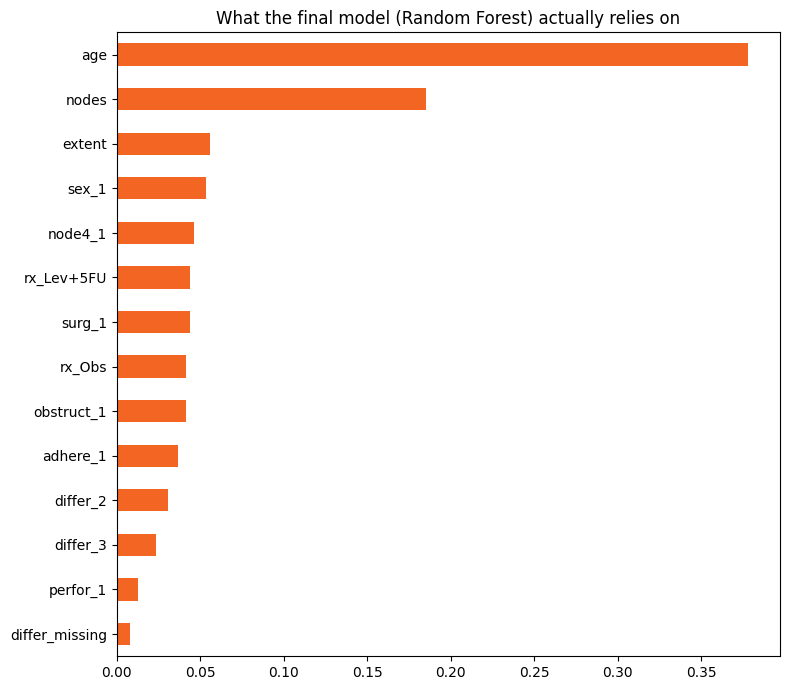

In [ ]:
fitted_preprocessor = final_model.named_steps["preprocessor"]
cat_encoder = fitted_preprocessor.named_transformers_["cat"].named_steps["encoder"]
encoded_cat_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_names)

classifier = final_model.named_steps["classifier"]

if hasattr(classifier, "feature_importances_"):
    importances = pd.Series(classifier.feature_importances_, index=all_feature_names).sort_values()
    plt.figure(figsize=(8, 7))
    importances.plot(kind="barh", color="#F26522")
    plt.title(f"What the final model ({model_name}) actually relies on")
    plt.tight_layout()
    plt.show()
else:
    coefs = pd.Series(classifier.coef_[0], index=all_feature_names).sort_values()
    plt.figure(figsize=(8, 7))
    coefs.plot(kind="barh", color="#F26522")
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title(f"What the final model ({model_name}) actually relies on")
    plt.tight_layout()
    plt.show()


### Closing the loop back to Step 1

Whatever came out on top, `nodes` almost certainly high given what the EDA already showed, connect it back to the business goal from the start of tonight: does this match what an oncologist would already suspect matters? Lymph node involvement being the strongest predictor of death risk is a well-established prognostic factor, not a surprise, so seeing the model converge on it is real validation. If something clinically implausible had shown up at the top instead, that would be a signal to dig deeper before trusting the model, a confidently wrong model is more dangerous than a simply less accurate one.

---
## Wrap-up: what pipelines actually bought us tonight

Look back at everything this pipeline did, split into small steps but still just a handful of ideas: preprocessing guaranteed to run identically on training data and on a new patient's record next year; hyperparameter tuning across preprocessing *and* model choices simultaneously, not one at a time by hand; a primary metric chosen deliberately in Step 1 and actually enforced through `refit`; and, going one step further than Canvas asks, a real cost scorer that optimizes for what actually matters instead of a generic proxy metric. And unlike every earlier session this week, none of it was synthetic, this was a real published clinical trial, real missing data, real clinical relationships showing up in the feature importance chart.

That's the whole week, closed. Logistic regression, decision trees, random forests, boosting, SVM, all of them are just different choices for the `classifier` step in exactly this same pipeline shape. The skill that actually generalizes to a real job isn't "I know how to fit a random forest," it's this: define the business goal first, build one clean, leakage-safe pipeline, let cross-validation pick the winner honestly, and evaluate it against the metric that was chosen for a reason, not the one that happened to look best.